# IoT Anomaly Detection: Objective 1 (dataset audit and device tiers)
CIC IoT-DIAD 2024 · Ledja Halltari · BCIT COMP 9080


## 1. Setup


In [4]:
# ========== SETUP: run this first ==========
from google.colab import drive
drive.mount("/content/drive")

import os, re, glob, gc
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

PROJECT  = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data"
PQ_DIR   = f"{PROJECT}/CIC-IoT-DIAD-2024-parquet"     # the dataset (Parquet)
WORK     = f"{PROJECT}/CIC-IoT-DIAD-2024-work"        # all results
SAVE     = WORK                                       # older cells use this name
FLOW_DIR = f"{PQ_DIR}/Anomaly Detection - Flow Based features"
PKT_DIR  = f"{PQ_DIR}/Device Identification_Anomaly Detection - Packet Based Features"

pd.set_option("display.max_rows", 200, "display.width", 200)
print("Dataset folder found:", os.path.isdir(PQ_DIR))
print("Results folder found:", os.path.isdir(WORK))
print("Parquet files:", len(glob.glob(f"{PQ_DIR}/**/*.parquet", recursive=True)), "(expected 312)")
print("Setup done ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset folder found: True
Results folder found: True
Parquet files: 312 (expected 312)
Setup done ✅


In [5]:
for folder in sorted(os.listdir(PQ_DIR)):
    path = os.path.join(PQ_DIR, folder)
    if os.path.isdir(path):
        n = len(glob.glob(f"{path}/**/*.parquet", recursive=True))
        print(f"{n:>4} files  in  {folder}")
print("README files:", len(glob.glob(f"{PQ_DIR}/**/*.txt", recursive=True)))

 132 files  in  Anomaly Detection - Flow Based features
 180 files  in  Device Identification_Anomaly Detection - Packet Based Features
README files: 2


## 2. Data


The dataset (CIC IoT-DIAD 2024) was downloaded from the CIC website and converted from CSV to Parquet (312 files, 11.29 GB, zstd compression), then verified file by file. The download and conversion code is kept in a separate archive notebook.

Packet README notes: the packet data has 134 features and supports device identification of approximately 45 device categories.


## 3. Exploratory data analysis


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

A. INVENTORY: every file, FULL row counts (no sampling)
Data folder: /content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-parquet
Files: 312  (Flow 132, Packet 180)
Rows:  Flow 27,810,004   Packet 35,672,839



,folder,family,files,rows,share_%
3,Flow,DoS,30,23143929,83.22
2,Flow,DDoS,61,3478814,12.51
5,Flow,Recon,1,442158,1.59
0,Flow,Benign,4,398330,1.43
4,Flow,Mirai,29,174588,0.63
6,Flow,Spoofing,3,157238,0.57
7,Flow,Web-Based,3,11328,0.04
1,Flow,BruteForce,1,3619,0.01
10,Packet,DDoS,101,22471481,62.99
12,Packet,Mirai,22,6097219,17.09


Flow: benign 1.4% of rows | largest family / smallest family = 6,395x  (DoS vs BruteForce)
Packet: benign 3.3% of rows | largest family / smallest family = 171x  (DDoS vs BruteForce)


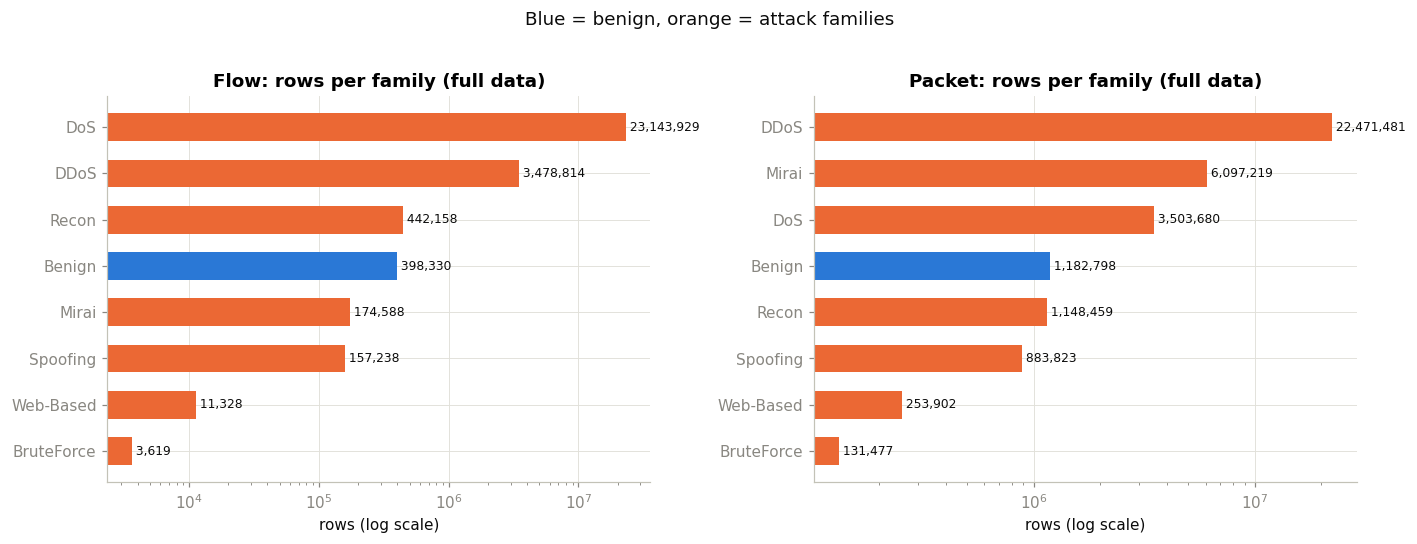

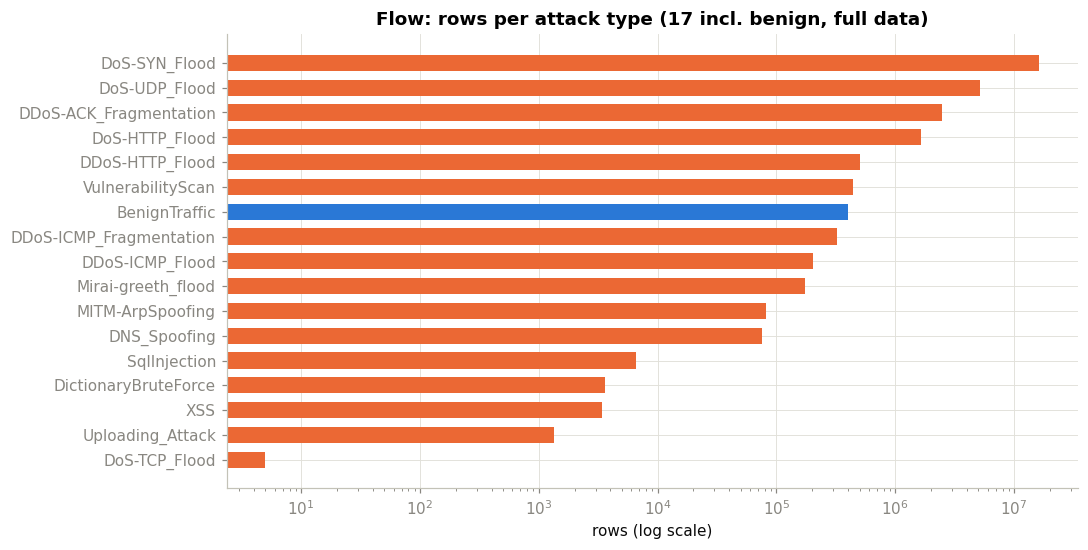

Flow rows per attack type:


,family,attack,rows
0,DoS,DoS-SYN_Flood,16290644
1,DoS,DoS-UDP_Flood,5210536
2,DDoS,DDoS-ACK_Fragmentation,2450086
3,DoS,DoS-HTTP_Flood,1642744
4,DDoS,DDoS-HTTP_Flood,505720
5,Recon,VulnerabilityScan,442158
6,Benign,BenignTraffic,398330
7,DDoS,DDoS-ICMP_Fragmentation,320757
8,DDoS,DDoS-ICMP_Flood,202251
9,Mirai,Mirai-greeth_flood,174588



B. SCHEMA: are the columns the same in benign and malicious files?
Flow: 84 columns | 132 of 132 files have exactly these columns
   Columns stored as numbers in some files but text in others: 0
Packet: 135 columns | 180 of 180 files have exactly these columns
   Columns stored as numbers in some files but text in others: 1


,folder,column,files_as_text,files_as_number
0,Packet,handshake_version,178,2



C. FLOW DATA: sample of every file, benign vs malicious
Flow sample: 1,610,887 rows from 132 files (20,000 per file max)

Columns with missing or infinite values (benign vs attack):


,missing_%_benign,missing_%_attack,infinite_benign,infinite_attack,unique_values
Flow Bytes/s,0.01,0.52,24,666,1075626
Flow Packets/s,0.00,0.00,31,8582,1183380



Constant columns (same value everywhere: useless for models): 7
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg']

Median of key features per family (compare each row with Benign):


,Flow Duration,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Flow IAT Mean,SYN Flag Count,Total Fwd Packet,FWD Init Win Bytes
family,,,,,,,,
Benign,61957656.0,35.9,0.3,54.6,3296258.9,0.0,5.0,1289.0
BruteForce,108819.0,302.8,19.2,40.3,102859.0,0.0,1.0,0.0
DDoS,3097237.0,140.5,1.4,78.0,979600.5,0.0,2.0,512.0
DoS,17386378.0,15.3,0.4,8.0,3548987.2,0.0,14.0,7.0
Mirai,234421.5,555.7,11.6,47.0,162027.5,0.0,2.0,0.0
Recon,43698.5,0.0,46.1,0.0,40581.3,1.0,1.0,1024.0
Spoofing,10175354.0,35.9,2.2,51.7,565998.9,0.0,4.0,523.0
Web-Based,210767.0,364.7,22.7,41.5,78972.6,0.0,2.0,0.0


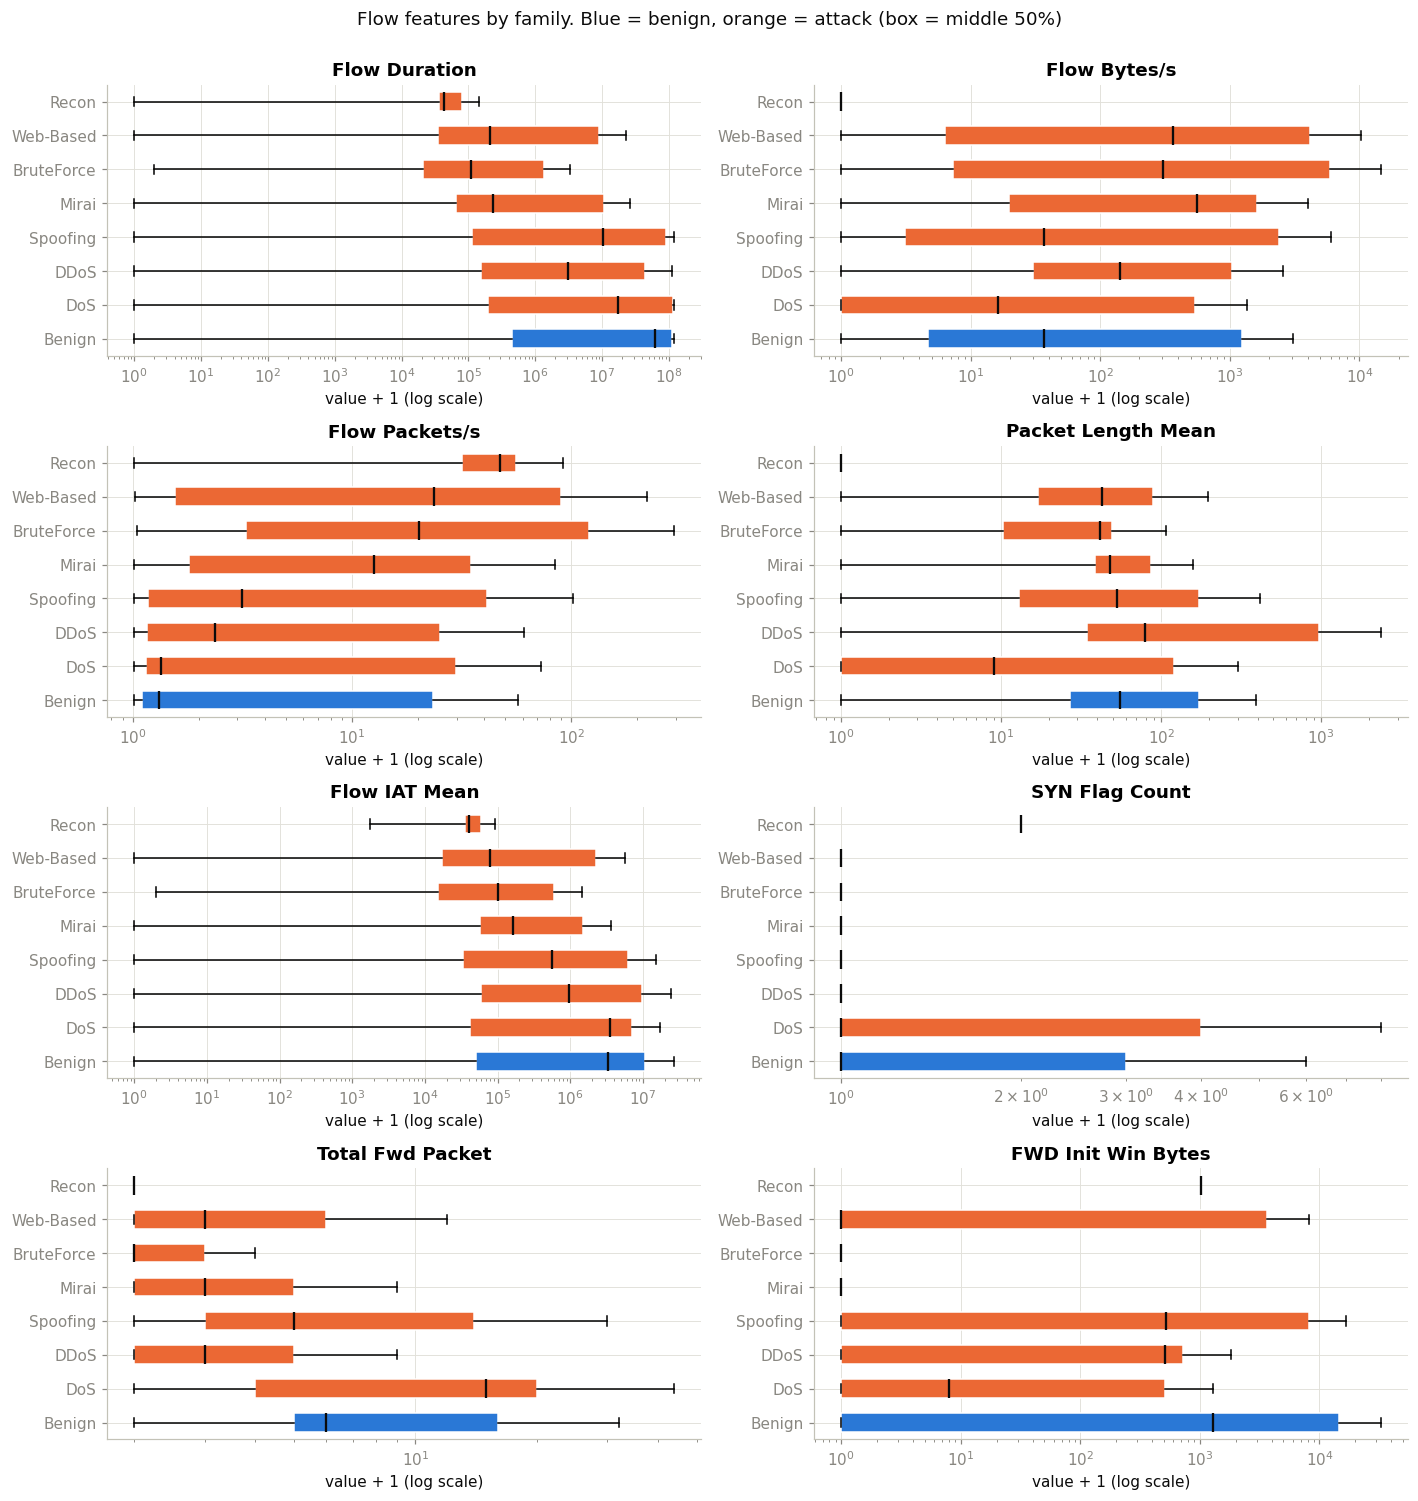


Near-duplicate flow features (|correlation| > 0.95): 23 pairs


,,abs_corr
Fwd Packet Length Mean,Fwd Segment Size Avg,1.000
Bwd Packet Length Mean,Bwd Segment Size Avg,1.000
Flow IAT Max,Idle Max,0.999
Packet Length Mean,Average Packet Size,0.996
Flow Packets/s,Fwd Packets/s,0.991
Bwd Header Length,ACK Flag Count,0.990
Flow Duration,Fwd IAT Total,0.990
Idle Mean,Idle Min,0.987
Fwd IAT Mean,Fwd IAT Min,0.979
Flow IAT Mean,Flow IAT Min,0.978



Protocol share per family (% of sampled flows):


Protocol,Other(0),TCP,UDP
family,,,
Benign,4.5,63.0,32.5
BruteForce,0.7,23.6,75.6
DDoS,2.0,61.8,36.2
DoS,0.5,54.4,45.1
Mirai,3.5,25.5,71.0
Recon,0.5,97.0,2.5
Spoofing,4.1,60.1,35.9
Web-Based,2.3,42.7,55.0



DONE ✅  Tables saved to the -work folder in your Drive (all start with eda_)


In [6]:
# =====================================================================
#  EDA CIC IoT-DIAD 2024, complete dataset (Parquet), benign + malicious
# =====================================================================
# NOTE: samples are taken from the START of each file (first rows), not random rows.
from google.colab import drive
drive.mount("/content/drive")

import os, re, glob
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# ---------- settings ----------
PQ_DIR = "/content/parquet" if os.path.isdir("/content/parquet") else "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-parquet"
SAVE   = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-work"
FLOW_ROWS_PER_FILE = 20_000     # sample size per flow file (for the detailed checks)
PKT_ROWS_PER_FILE  = 3_000      # sample size per packet file (packet files are wide)
os.makedirs(SAVE, exist_ok=True)
pd.set_option("display.max_rows", 200, "display.max_columns", 50, "display.width", 200)

BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
                     "axes.axisbelow": True, "axes.titleweight": "bold", "axes.titlesize": 12})

def section(title):
    print("\n" + "=" * 80 + f"\n{title}\n" + "=" * 80)

def head_rows(path, n):
    """First n rows of a Parquet file, without loading the whole file."""
    for batch in pq.ParquetFile(path).iter_batches(batch_size=n):
        return batch.to_pandas()
    return pd.DataFrame()

ID_FLOW = ["Flow ID", "Src IP", "Dst IP", "Src Port", "Timestamp", "Label"]
ID_PKT  = ["stream", "src_mac", "dst_mac", "src_ip", "dst_ip", "src_port", "eth_src_oui", "eth_dst_oui", "device_mac"]

# =====================================================================
section("A. INVENTORY: every file, FULL row counts (no sampling)")
# =====================================================================
inv = []
for p in sorted(glob.glob(f"{PQ_DIR}/**/*.parquet", recursive=True)):
    rel = os.path.relpath(p, PQ_DIR)
    parts = rel.split(os.sep)
    folder = "Flow" if "flow" in parts[0].lower() else "Packet"
    family = "Benign" if parts[1].lower().startswith("benign") else parts[1]
    stem = os.path.basename(p)[:-len(".parquet")].replace(".pcap_Flow", "")
    attack = re.sub(r"[\d\-_]+$", "", stem)
    md = pq.ParquetFile(p).metadata
    inv.append({"folder": folder, "family": family, "attack": attack, "file": rel,
                "rows": md.num_rows, "columns": md.num_columns, "MB": round(os.path.getsize(p) / 1e6, 1)})
inv = pd.DataFrame(inv)
inv["is_attack"] = inv["family"] != "Benign"
inv.to_csv(f"{SAVE}/eda_inventory.csv", index=False)
print(f"Data folder: {PQ_DIR}")
print(f"Files: {len(inv)}  (Flow {sum(inv.folder == 'Flow')}, Packet {sum(inv.folder == 'Packet')})")
print(f"Rows:  Flow {inv.loc[inv.folder=='Flow','rows'].sum():,}   Packet {inv.loc[inv.folder=='Packet','rows'].sum():,}\n")

fam = inv.groupby(["folder", "family"]).agg(files=("file", "size"), rows=("rows", "sum")).reset_index()
fam["share_%"] = (fam["rows"] / fam.groupby("folder")["rows"].transform("sum") * 100).round(2)
display(fam.sort_values(["folder", "rows"], ascending=[True, False]))

for folder in ["Flow", "Packet"]:
    f = fam[fam.folder == folder].set_index("family")["rows"]
    if len(f):
        b = f.get("Benign", 0)
        print(f"{folder}: benign {b/f.sum()*100:.1f}% of rows | largest family / smallest family = "
              f"{f.max()/max(f.min(),1):,.0f}x  ({f.idxmax()} vs {f.idxmin()})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, folder in zip(axes, ["Flow", "Packet"]):
    f = fam[fam.folder == folder].sort_values("rows")
    ax.barh(f["family"], f["rows"], color=[BLUE if x == "Benign" else ORANGE for x in f["family"]], height=0.6)
    ax.set_xscale("log"); ax.set_title(f"{folder}: rows per family (full data)"); ax.set_xlabel("rows (log scale)")
    for y, v in enumerate(f["rows"]):
        ax.text(v, y, f" {v:,}", va="center", color=INK, fontsize=8)
fig.suptitle("Blue = benign, orange = attack families", color=INK, y=1.02)
plt.tight_layout(); plt.show()

att = inv[inv.folder == "Flow"].groupby(["family", "attack"])["rows"].sum().reset_index().sort_values("rows")
plt.figure(figsize=(10, max(4, 0.3 * len(att))))
plt.barh(att["attack"], att["rows"], color=[BLUE if x == "Benign" else ORANGE for x in att["family"]], height=0.65)
plt.xscale("log"); plt.title(f"Flow: rows per attack type ({len(att)} incl. benign, full data)"); plt.xlabel("rows (log scale)")
plt.tight_layout(); plt.show()
print("Flow rows per attack type:")
display(att.sort_values("rows", ascending=False).reset_index(drop=True))

# =====================================================================
section("B. SCHEMA: are the columns the same in benign and malicious files?")
# =====================================================================
schema_rows = []
for folder in ["Flow", "Packet"]:
    files = inv[inv.folder == folder]
    schemas = {r.file: pq.read_schema(os.path.join(PQ_DIR, r.file)) for r in files.itertuples()}
    names = {f: tuple(s.names) for f, s in schemas.items()}
    usual = pd.Series(list(names.values())).value_counts().index[0]
    odd = [f for f, n in names.items() if n != usual]
    print(f"{folder}: {len(usual)} columns | {len(files) - len(odd)} of {len(files)} files have exactly these columns")
    for f in odd:
        print(f"   ⚠️ different columns: {f}")
    types = pd.DataFrame({f: {fld.name: str(fld.type) for fld in s} for f, s in schemas.items()}).T
    mixed = [c for c in types.columns if types[c].dropna().nunique() > 1]
    for c in mixed:
        n_text = types[c].astype(str).str.contains("string").sum()
        schema_rows.append({"folder": folder, "column": c, "files_as_text": n_text, "files_as_number": len(types) - n_text})
    print(f"   Columns stored as numbers in some files but text in others: {len(mixed)}")
mixed_df = pd.DataFrame(schema_rows)
if len(mixed_df):
    display(mixed_df)
mixed_df.to_csv(f"{SAVE}/eda_mixed_type_columns.csv", index=False)

# =====================================================================
section("C. FLOW DATA: sample of every file, benign vs malicious")
# =====================================================================
parts = []
for r in inv[inv.folder == "Flow"].itertuples():
    d = head_rows(os.path.join(PQ_DIR, r.file), FLOW_ROWS_PER_FILE)
    d["family"], d["attack"], d["is_attack"] = r.family, r.attack, int(r.is_attack)
    parts.append(d)
flow = pd.concat(parts, ignore_index=True)
num_cols = [c for c in flow.columns if c not in ID_FLOW + ["family", "attack", "is_attack"]]
for c in num_cols:
    flow[c] = pd.to_numeric(flow[c], errors="coerce")
print(f"Flow sample: {len(flow):,} rows from {len(parts)} files ({FLOW_ROWS_PER_FILE:,} per file max)")

X = flow[num_cols]
ben, mal = X[flow.is_attack == 0], X[flow.is_attack == 1]
q = pd.DataFrame({
    "missing_%_benign":   (ben.isna().mean() * 100).round(2),
    "missing_%_attack":   (mal.isna().mean() * 100).round(2),
    "infinite_benign":    np.isinf(ben).sum(),
    "infinite_attack":    np.isinf(mal).sum(),
    "unique_values":      X.nunique(dropna=False),
})
q.to_csv(f"{SAVE}/eda_flow_quality.csv")
print("\nColumns with missing or infinite values (benign vs attack):")
display(q[(q.iloc[:, :4] > 0).any(axis=1)])
constant = q.index[q.unique_values <= 1].tolist()
print(f"\nConstant columns (same value everywhere: useless for models): {len(constant)}")
print(constant)

KEY = [c for c in ["Flow Duration", "Flow Bytes/s", "Flow Packets/s", "Packet Length Mean", "Flow IAT Mean",
                   "SYN Flag Count", "Total Fwd Packet", "FWD Init Win Bytes"] if c in X.columns]
med = flow.groupby("family")[KEY].median().round(1)
print("\nMedian of key features per family (compare each row with Benign):")
display(med)

Xc = X.replace([np.inf, -np.inf], np.nan)
order = flow.groupby("family")["Flow Packets/s"].median().sort_values().index if "Flow Packets/s" in KEY else sorted(flow.family.unique())
rows_n = int(np.ceil(len(KEY) / 2))
fig, axes = plt.subplots(rows_n, 2, figsize=(13, 3.4 * rows_n))
axes = np.array(axes).reshape(-1)
for ax, feat in zip(axes, KEY):
    data = [Xc.loc[flow.family == c, feat].dropna().clip(lower=0) + 1 for c in order]
    bp = ax.boxplot(data, vert=False, showfliers=False, patch_artist=True, widths=0.55,
                    medianprops=dict(color=INK, linewidth=1.5))
    for i, b in enumerate(bp["boxes"]):
        b.set(facecolor=BLUE if order[i] == "Benign" else ORANGE, edgecolor="white")
    ax.set_yticks(range(1, len(order) + 1)); ax.set_yticklabels(order)
    ax.set_xscale("log"); ax.set_title(feat); ax.set_xlabel("value + 1 (log scale)")
for ax in axes[len(KEY):]:
    ax.set_visible(False)
fig.suptitle("Flow features by family. Blue = benign, orange = attack (box = middle 50%)", color=INK, y=1.0)
plt.tight_layout(); plt.show()

usable = [c for c in num_cols if c not in constant and c not in ("Dst Port", "Protocol")]
corr = Xc[usable].corr().abs()
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack().sort_values(ascending=False)
print(f"\nNear-duplicate flow features (|correlation| > 0.95): {int((pairs > 0.95).sum())} pairs")
display(pairs[pairs > 0.95].head(25).round(3).to_frame("abs_corr"))

if "Protocol" in flow.columns:
    proto = flow["Protocol"].map({6: "TCP", 17: "UDP", 1: "ICMP", 0: "Other(0)"}).fillna("Other")
    print("\nProtocol share per family (% of sampled flows):")
    display(pd.crosstab(flow["family"], proto, normalize="index").mul(100).round(1))

section("DONE ✅  Tables saved to the -work folder in your Drive (all start with eda_)")

In [7]:
from google.colab import drive
drive.mount("/content/drive")

import os, gc
import pandas as pd
import pyarrow.parquet as pq

PQ_DIR = "/content/parquet" if os.path.isdir("/content/parquet") else "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-parquet"
SAVE   = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-work"
PKT_ROWS_PER_FILE = 1_000
pd.set_option("display.max_rows", 200)

inv = pd.read_csv(f"{SAVE}/eda_inventory.csv")
pk_files = inv[inv.folder == "Packet"]

parts = []
for i, r in enumerate(pk_files.itertuples(), 1):
    pf = pq.ParquetFile(os.path.join(PQ_DIR, r.file))
    batch = next(pf.iter_batches(batch_size=PKT_ROWS_PER_FILE), None)
    if batch is None:
        continue
    d = batch.to_pandas()
    d["family"], d["is_attack"] = r.family, int(r.is_attack)
    parts.append(d)
    if i % 30 == 0:
        print(f"  read {i}/{len(pk_files)} packet files")
pkt = pd.concat(parts, ignore_index=True); del parts; gc.collect()
print(f"\nPacket sample: {len(pkt):,} rows from {len(pk_files)} files")

feat = [c for c in pkt.columns if c not in ["family", "is_attack"]]
pm = pd.DataFrame({
    "missing_%_benign": (pkt.loc[pkt.is_attack == 0, feat].isna().mean() * 100).round(1),
    "missing_%_attack": (pkt.loc[pkt.is_attack == 1, feat].isna().mean() * 100).round(1),
    "unique_values":    pkt[feat].nunique(dropna=False),
})
pm.to_csv(f"{SAVE}/eda_packet_missing.csv")
pm.to_csv("/content/eda_packet_missing.csv")        # extra copy on Colab's disk
print("✅ Saved eda_packet_missing.csv")

print("\nMost-empty packet columns:")
display(pm.sort_values("missing_%_benign", ascending=False).head(30))
print(f"\nConstant packet columns: {pm.index[pm.unique_values <= 1].tolist()}")

if "highest_layer" in pkt.columns:
    hl = pkt["highest_layer"].astype(str)
    top = hl.value_counts().index[:8]
    print("\nTop protocol share per family (% of sampled packets):")
    display(pd.crosstab(pkt["family"], hl.where(hl.isin(top), "other"), normalize="index").mul(100).round(1))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  read 30/180 packet files
  read 60/180 packet files
  read 90/180 packet files
  read 120/180 packet files
  read 150/180 packet files
  read 180/180 packet files

Packet sample: 180,000 rows from 180 files
✅ Saved eda_packet_missing.csv

Most-empty packet columns:


,missing_%_benign,missing_%_attack,unique_values
dns_query_type,97.3,99.0,5
src_ip_1_var,11.9,6.2,30610
src_ip_mac_1_var,11.5,5.8,29957
stream_jitter_1_var,10.8,51.9,87895
src_ip_5_var,9.8,4.7,34670
src_ip_30_var,9.2,4.0,37218
src_ip_10_var,9.2,4.1,36199
src_ip_60_var,9.2,4.0,37282
stream_jitter_5_var,9.2,51.0,89567
stream_jitter_10_var,9.0,50.7,90159



Constant packet columns: ['handshake_ciphersuites', 'http_host']

Top protocol share per family (% of sampled packets):


highest_layer,ARP,DATA,DNS,ICMP,TCP,TLS,UDP,_WS.MALFORMED,other
family,,,,,,,,,
Benign,1.7,0.4,2.7,1.0,70.4,13.4,7.6,0.0,2.8
BruteForce,3.2,0.4,1.0,0.7,34.4,42.4,13.9,0.0,4.0
DDoS,0.9,21.5,0.6,8.6,35.2,1.1,27.5,3.2,1.3
DoS,0.6,0.0,0.5,1.0,52.0,1.6,42.8,0.0,1.6
Mirai,0.5,0.0,0.3,0.2,3.4,1.0,93.4,0.6,0.5
Recon,5.1,1.1,7.4,2.7,43.2,12.2,19.1,0.0,9.2
Spoofing,3.1,0.5,1.7,0.3,57.8,23.5,9.8,0.1,3.2
Web-Based,6.7,1.9,7.2,3.9,34.1,12.8,22.2,0.0,11.1


## 4. Linking flows to devices


In [8]:
import os, re, glob
import pandas as pd
import pyarrow.parquet as pq

PQ_DIR = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-parquet"
SAVE   = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-work"
MAC_RE = re.compile(r"^([0-9a-f]{2}:){5}[0-9a-f]{2}$", re.I)

benign = glob.glob(f"{PQ_DIR}/Device Identification_Anomaly Detection - Packet Based Features/BenignTraffic/*.parquet")
print(f"Benign packet files: {len(benign)}  (expected 4)")

counts = {}
for p in benign:
    for batch in pq.ParquetFile(p).iter_batches(batch_size=1_000_000, columns=["src_mac", "src_ip"]):
        b = batch.to_pandas()
        for (dev, ip), n in b.groupby(["src_mac", "src_ip"], dropna=False).size().items():
            counts[(dev, str(ip))] = counts.get((dev, str(ip)), 0) + n

ipdf = pd.Series(counts).rename("packets").reset_index()
ipdf.columns = ["device", "ip", "packets"]
lan = ipdf[ipdf["ip"].str.startswith("192.168.137.")]

devices = pd.DataFrame({"benign_packets": ipdf.groupby("device")["packets"].sum()})
devices["kind"] = ["unnamed MAC" if MAC_RE.match(str(d)) else "named device" for d in devices.index]
devices["n_lan_ips"] = lan.groupby("device")["ip"].nunique()
devices["lan_ips"] = lan.groupby("device")["ip"].apply(lambda s: ", ".join(sorted(s)))
devices["n_lan_ips"] = devices["n_lan_ips"].fillna(0).astype(int)
devices = devices.sort_values("benign_packets", ascending=False)

os.makedirs(SAVE, exist_ok=True)
devices.to_csv(f"{SAVE}/device_ip_map_benign.csv")
print(f"✅ Rebuilt the address book: {len(devices)} entries, "
      f"{(devices.kind == 'named device').sum()} named devices  (expected 73 and 54)")

Benign packet files: 4  (expected 4)
✅ Rebuilt the address book: 73 entries, 54 named devices  (expected 73 and 54)


In [10]:
from google.colab import drive
drive.mount("/content/drive")

import os, re, glob
import pandas as pd
import pyarrow.parquet as pq

PQ_DIR   = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-parquet"
SAVE     = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-work"
FLOW_DIR = os.path.join(PQ_DIR, "Anomaly Detection - Flow Based features")
pd.set_option("display.max_rows", 200)

# ---- 1. the address book (named devices only, skip shared numbers) ----
everyone = pd.read_csv(f"{SAVE}/device_ip_map_benign.csv", index_col=0)
ip_count = {}
for ips in everyone["lan_ips"].dropna():
    for ip in ips.split(", "):
        ip_count[ip] = ip_count.get(ip, 0) + 1
book = everyone[(everyone["kind"] == "named device") & everyone["lan_ips"].notna()]
ip2dev = {ip: dev for dev, ips in book["lan_ips"].items() for ip in ips.split(", ") if ip_count[ip] == 1}
print(f"Address book: {len(book)} devices, {len(ip2dev)} phone numbers")

# ---- 2. count flows per device in every flow file ----
paths = sorted(glob.glob(f"{FLOW_DIR}/**/*.parquet", recursive=True))
print(f"Flow files: {len(paths)}  (expected 132)\n")
rows, totals = [], []
for i, p in enumerate(paths, 1):
    rel = os.path.relpath(p, FLOW_DIR)
    family = "Benign" if rel.split(os.sep)[0].lower().startswith("benign") else rel.split(os.sep)[0]
    attack = re.sub(r"[\d\-_]+$", "", os.path.basename(p)[:-len(".parquet")].replace(".pcap_Flow", ""))
    counts, total, linked = {}, 0, 0
    for batch in pq.ParquetFile(p).iter_batches(batch_size=1_000_000, columns=["Src IP", "Dst IP"]):
        b = batch.to_pandas()
        s = b["Src IP"].astype(str).str.strip().map(ip2dev)
        d = b["Dst IP"].astype(str).str.strip().map(ip2dev)
        d = d.where(d != s)                                   # don't count a device twice in one flow
        for dev, n in pd.concat([s, d]).dropna().value_counts().items():
            counts[dev] = counts.get(dev, 0) + n
        total += len(b)
        linked += int((s.notna() | d.notna()).sum())
    rows += [{"file": rel, "device": dev, "family": family, "attack": attack, "flows": n} for dev, n in counts.items()]
    totals.append({"file": rel, "family": family, "attack": attack, "flows": total, "flows_with_device": linked})
    if i % 20 == 0 or i == len(paths):
        print(f"  counted {i}/{len(paths)} files")

long = pd.DataFrame(rows)
totals = pd.DataFrame(totals)
long.to_csv(f"{SAVE}/flows_per_device_detail_v2.csv", index=False)
totals.to_csv(f"{SAVE}/flow_file_totals_v2.csv", index=False)

# ---- 3. per-device table ----
is_benign = long["family"] == "Benign"
per_device = pd.DataFrame({
    "benign_flows":    long[is_benign].groupby("device")["flows"].sum(),
    "attack_flows":    long[~is_benign].groupby("device")["flows"].sum(),
    "attack_types":    long[~is_benign].groupby("device")["attack"].nunique(),
    "attack_families": long[~is_benign].groupby("device")["family"].nunique(),
}).reindex(book.index).fillna(0).astype(int).sort_values("benign_flows", ascending=False)
per_device.to_csv(f"{SAVE}/flows_per_device_v2.csv")

# ---- 4. checks + summary ----
fams = sorted(f for f in totals["family"].unique() if f != "Benign")
print("\n================ CHECK ================ ")
print(f"Files counted:            {len(totals)}  (expected 132)")
print(f"Attack families found:    {len(fams)}  {fams}")
print(f"Attack types found:       {totals.loc[totals.family != 'Benign', 'attack'].nunique()}  (expected 16)")
print(f"Flows linked to a device: {totals.flows_with_device.sum():,} of {totals.flows.sum():,} "
      f"({totals.flows_with_device.sum() / totals.flows.sum() * 100:.1f}%)")
print(f"Devices with benign flows: {(per_device.benign_flows > 0).sum()} / {len(per_device)}")
print(f"Devices with attack flows: {(per_device.attack_flows > 0).sum()} / {len(per_device)}")

print("\nHow many devices pass at different 'enough benign data' lines (one-third of 54 = 18):")
for line in [500, 1000, 2000, 5000, 10000]:
    n = int((per_device.benign_flows >= line).sum())
    print(f"  at least {line:>6,} benign flows: {n:>2} devices  {'✅ more than one-third' if n >= 18 else '❌ less than one-third'}")

print("\nPer-device table (saved as flows_per_device_v2.csv):")
display(per_device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Address book: 54 devices, 57 phone numbers
Flow files: 132  (expected 132)

  counted 20/132 files
  counted 40/132 files
  counted 60/132 files
  counted 80/132 files
  counted 100/132 files
  counted 120/132 files
  counted 132/132 files

================ CHECK ================ 
Files counted:            132  (expected 132)
Attack families found:    7  ['BruteForce', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web-Based']
Attack types found:       16  (expected 16)
Flows linked to a device: 11,835,286 of 27,810,004 (42.6%)
Devices with benign flows: 53 / 54
Devices with attack flows: 53 / 54

How many devices pass at different 'enough benign data' lines (one-third of 54 = 18):
  at least    500 benign flows: 49 devices  ✅ more than one-third
  at least  1,000 benign flows: 43 devices  ✅ more than one-third
  at least  2,000 benign flows: 23 devices  ✅ mor

,benign_flows,attack_flows,attack_types,attack_families
device,,,,
Home Eye Camera,51123,82888,8,6
harman kardon (Ampak Technology),28729,3238,4,3
Wyze Camera,27849,16403,6,2
LG Smart TV,14668,5506,7,4
Amazon Echo Show,13488,26116,8,4
Arlo Q Indoor Camera,11781,10543,9,5
Google Nest Mini Speaker,10949,13897,5,4
Amazon Echo Studio,9487,3587,3,2
Eufy HomeBase 2,9367,479139,11,5


The schema was checked across all 312 files: every file in the flow-based folder has the same 84 columns, and every file in the packet-based folder has the same 135 columns. The only inconsistency is that handshake_version is stored as text in most packet files. Labels are not stored in the rows; they come from the folder and file names, which give 8 attack families, with 16 attack types in the flow data and 27 in the packet data. The data is heavily imbalanced. Only 1.4% of flows and 3.3% of packets are benign, and DoS traffic alone makes up 83% of all flows. The missing-value analysis found infinite values in two flow-rate columns and seven constant flow columns. In the packet data, the jitter, stream and variance columns are empty much more often in attack rows than in benign rows, which could let a model detect attacks from missingness alone. Flows were mapped to devices with an IP address book built from benign packet traffic. This mapping linked 42.6% of flows to 53 of the 54 identifiable devices, with benign flow counts ranging from 51,123 down to 14 per device. The dataset documentation describes 105 devices, but only 54 can be identified by IP in the traffic, likely because the remainder include Zigbee and Z-Wave devices that do not appear by IP address; this is noted as a limitation.


## 5. Learning curve (benign threshold)


In [12]:
import os, glob, numpy as np, pandas as pd, pyarrow.parquet as pq
from google.colab import drive
drive.mount('/content/drive')

PQ_DIR   = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-parquet"
WORK     = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-work"
FLOW_DIR = f"{PQ_DIR}/Anomaly Detection - Flow Based features"
CACHE    = f"{WORK}/lc_rows.parquet"

MIN_BENIGN_FOR_TEST = 10_000      # only data-rich devices take part
EXCLUDE             = ["raspberry"]  # not data-rich anyway (185 benign flows); a later check showed it is a victim, not the attacker
MAX_ATTACK_PER_FILE = 300         # attack rows kept per device per attack file
MAX_SCAN_PER_FILE   = 3_000_000   # stop reading a huge attack file after this many rows

ID_COLS = ["Flow ID", "Src IP", "Dst IP", "Src Port", "Dst Port", "Timestamp", "Label",
           "device", "source", "is_attack"]

# 1. Which devices have lots of benign data?
counts = pd.read_csv(f"{WORK}/flows_per_device_v2.csv")
name_col = counts.columns[0]
rich = counts[counts["benign_flows"] >= MIN_BENIGN_FOR_TEST]
rich = rich[~rich[name_col].str.lower().str.contains("|".join(EXCLUDE))]
devices = rich[name_col].tolist()
print(f"{len(devices)} data-rich devices:")
print(rich[[name_col, "benign_flows", "attack_flows"]].to_string(index=False))

# 2. Address book -> IP of each chosen device (same rules as the recount)
import re
book = pd.read_csv(f"{WORK}/device_ip_map_benign.csv")
print("Address book columns:", list(book.columns))

name_c = book.columns[0]                                   # device name / MAC column
ip_c   = "lan_ips" if "lan_ips" in book.columns else [c for c in book.columns if "ip" in c.lower()][0]
IP_RE  = re.compile(r"192\.168\.137\.\d{1,3}")

# one row per (device, IP)
pairs = [(row[name_c], ip, row.get("kind", "named device"))
         for _, row in book.iterrows()
         for ip in set(IP_RE.findall(str(row[ip_c])))]
pairs = pd.DataFrame(pairs, columns=["name", "ip", "kind"])

# IPs used by more than one entry are ambiguous -> skip them
n_owners = pairs.groupby("ip")["name"].nunique()
shared   = set(n_owners[n_owners > 1].index)
named    = pairs[(pairs["kind"] == "named device") & (~pairs["ip"].isin(shared))]

ip2dev  = {ip: d for ip, d in zip(named["ip"], named["name"]) if d in devices}
missing = set(devices) - set(ip2dev.values())
print("IPs found for chosen devices:", len(ip2dev))
print("Devices with no IP found:", missing or "none")

def tag_device(df):
    return df["Src IP"].map(ip2dev).fillna(df["Dst IP"].map(ip2dev))

def clean(df):
    for c in df.columns:
        if c not in ID_COLS:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")
        else:
            df[c] = df[c].astype(str) if c != "is_attack" else df[c]
    return df

# 3. Collect rows (or load the saved copy)
if os.path.exists(CACHE):
    data = pd.read_parquet(CACHE)
    print("\nLoaded saved rows:", len(data))
else:
    files = sorted(glob.glob(f"{FLOW_DIR}/**/*.parquet", recursive=True))
    parts = []
    for i, p in enumerate(files, 1):
        rel = os.path.relpath(p, FLOW_DIR)
        is_benign = "benign" in rel.lower()
        try:
            pf = pq.ParquetFile(p)
            if "Src IP" not in pf.schema_arrow.names:
                print(f"[{i}/{len(files)}] skip (no IP columns): {rel}")
                continue
            got = {d: 0 for d in devices}
            scanned = 0
            for b in pf.iter_batches(batch_size=200_000):
                df = b.to_pandas()
                scanned += len(df)
                df["device"] = tag_device(df)
                df = df[df["device"].notna()].copy()
                if not is_benign and len(df):
                    k = df.groupby("device").cumcount() + df["device"].map(got)
                    df = df[k < MAX_ATTACK_PER_FILE].copy()
                for d, n in df["device"].value_counts().items():
                    got[d] += n
                if len(df):
                    df["source"] = rel
                    df["is_attack"] = 0 if is_benign else 1
                    parts.append(clean(df))
                if not is_benign and (all(v >= MAX_ATTACK_PER_FILE for v in got.values())
                                      or scanned >= MAX_SCAN_PER_FILE):
                    break
            print(f"[{i}/{len(files)}] {'BENIGN' if is_benign else 'attack'}  kept {sum(got.values()):>7,}  {rel}")
        except Exception as e:
            print(f"[{i}/{len(files)}] ERROR {rel}: {e}")
    data = pd.concat(parts, ignore_index=True)
    data.to_parquet(CACHE, index=False)
    print("\nSaved", len(data), "rows to", CACHE)

print("\nRows per device (0 = benign, 1 = attack):")
print(data.groupby(["device", "is_attack"]).size().unstack(fill_value=0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
7 data-rich devices:
                          device  benign_flows  attack_flows
                 Home Eye Camera         51123         82888
harman kardon (Ampak Technology)         28729          3238
                     Wyze Camera         27849         16403
                     LG Smart TV         14668          5506
                Amazon Echo Show         13488         26116
            Arlo Q Indoor Camera         11781         10543
        Google Nest Mini Speaker         10949         13897
Address book columns: ['device', 'benign_packets', 'kind', 'n_lan_ips', 'lan_ips']
IPs found for chosen devices: 7
Devices with no IP found: none

Loaded saved rows: 196406

Rows per device (0 = benign, 1 = attack):
is_attack                             0     1
device                                       
Amazon Echo Show                  13488  7368
Arlo Q I

In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score

SIZES       = [100, 250, 500, 1000, 2000, 5000, 8000]
SEEDS       = [0, 1, 2, 3, 4]
TEST_BENIGN = 2000
TEST_ATTACK = 2000

feat = [c for c in data.columns if c not in ID_COLS]
X = data[feat].replace([np.inf, -np.inf], np.nan).astype("float32")
const = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
X = X.drop(columns=const)
print(f"Using {X.shape[1]} features (dropped {len(const)} constant ones)")

rows = []
for dev in data["device"].unique():
    ben = X[(data["device"] == dev) & (data["is_attack"] == 0)]
    att = X[(data["device"] == dev) & (data["is_attack"] == 1)]
    if len(att) < 200 or len(ben) < TEST_BENIGN + 1000:
        print(f"skip {dev}: benign={len(ben)}, attack={len(att)}")
        continue
    print(f"testing {dev}  (benign={len(ben):,}, attack={len(att):,})")
    for seed in SEEDS:
        order  = np.random.default_rng(seed).permutation(len(ben))
        test_b = ben.iloc[order[:TEST_BENIGN]]
        pool   = ben.iloc[order[TEST_BENIGN:]]
        test_a = att.sample(min(TEST_ATTACK, len(att)), random_state=seed)
        test   = pd.concat([test_b, test_a])
        y      = np.r_[np.zeros(len(test_b)), np.ones(len(test_a))]
        for n in SIZES:
            if n > len(pool):
                continue
            train = pool.iloc[:n]
            med   = train.median()
            tr    = train.fillna(med).fillna(0)
            te    = test.fillna(med).fillna(0)
            model = IsolationForest(n_estimators=200, random_state=seed, n_jobs=-1).fit(tr)
            score = -model.score_samples(te)               # higher = more suspicious
            cut   = np.quantile(-model.score_samples(tr), 0.95)
            pred  = score > cut
            rows.append(dict(device=dev, seed=seed, n_train=n,
                             pr_auc=average_precision_score(y, score),
                             roc_auc=roc_auc_score(y, score),
                             recall=pred[y == 1].mean(),
                             fpr=pred[y == 0].mean()))

res = pd.DataFrame(rows)
print(res)
res.to_csv(f"{WORK}/learning_curve_results.csv", index=False)
print("\nDone. Saved learning_curve_results.csv")

Using 70 features (dropped 7 constant ones)
testing Arlo Q Indoor Camera  (benign=11,781, attack=6,390)
testing Amazon Echo Show  (benign=13,488, attack=7,368)
testing Home Eye Camera  (benign=51,123, attack=6,796)
testing Wyze Camera  (benign=27,849, attack=3,530)
testing Google Nest Mini Speaker  (benign=10,949, attack=6,617)
testing harman kardon (Ampak Technology)  (benign=28,729, attack=2,920)
testing LG Smart TV  (benign=14,668, attack=4,198)
                   device  seed  n_train    pr_auc   roc_auc  recall     fpr
0    Arlo Q Indoor Camera     0      100  0.705947  0.784207  0.2170  0.0805
1    Arlo Q Indoor Camera     0      250  0.800667  0.832876  0.2965  0.0755
2    Arlo Q Indoor Camera     0      500  0.806574  0.826564  0.3000  0.0745
3    Arlo Q Indoor Camera     0     1000  0.814368  0.822315  0.3165  0.0520
4    Arlo Q Indoor Camera     0     2000  0.820813  0.828965  0.3145  0.0510
..                    ...   ...      ...       ...       ...     ...     ...
240     

The thresholds are 1,000 benign flows, 100 attack flows and 3 attack types per device. The benign threshold comes from a learning-curve experiment: model quality stopped improving after about 250 benign flows, and 1,000 was chosen to leave a safety margin.
What a threshold is, simply: a cut-off line for "enough data". A device above all three lines gets its own model. A device below any of them has to share.
The learning-curve experiment (benign threshold)
Question: how many normal flows does a model need to see before it stops getting better?
Method:
1. Took the 7 devices with more than 10,000 benign flows (the Raspberry Pi was left out of this test).
2. Collected all their benign flows and up to 300 attack flows per device from every attack file, so many attack types are represented. Saved as lc_rows.parquet.
3. Removed identifier columns (IPs, ports, Flow ID, timestamp) and the 7 constant columns. Replaced infinite values with missing values and filled them with the training median.
4. For each device, held back a fixed test set of 2,000 benign and up to 2,000 attack flows that the model never trained on.
5. Trained Isolation Forest (200 trees) on 100, 250, 500, 1,000, 2,000, 5,000 and 8,000 benign flows.
6. Measured PR-AUC on the test set, plus recall and false positive rate at a cut-off set at the 95th percentile of training scores.
7. Repeated everything with 5 different random seeds and averaged.

Average over all devices and repeats:
         pr_auc  recall    fpr  pr_auc_spread
n_train                                      
100       0.670   0.175  0.060          0.072
250       0.730   0.273  0.061          0.075
500       0.731   0.260  0.055          0.073
1000      0.732   0.244  0.053          0.074
2000      0.730   0.240  0.052          0.078
5000      0.731   0.238  0.050          0.079
8000      0.731   0.236  0.050          0.078

PR-AUC per device:
n_train                            100    250    500    1000   2000   5000   8000
device                                                                           
Amazon Echo Show                  0.551  0.602  0.608  0.609  0.599  0.597  0.599
Arlo Q Indoor Camera              0.682  0.795  0.802  0.809  0.817  0.820  0.814
Google Nest Mini Speaker          0.627  0.713  0.700  0.695  0.688  0.687  0.686
Home Eye Camera                   0.653  0.703  0.702  0.704  0.702  0.704  0.704
LG Smart TV                       0.

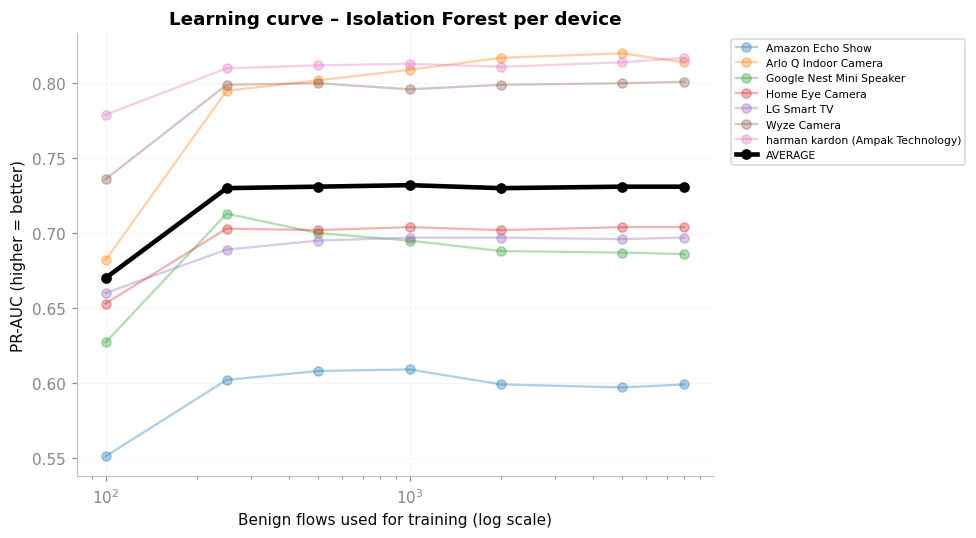


Best average PR-AUC = 0.732
Curve levels off at about 250 benign flows (within 0.01 of best)

Where each device levels off:
  Amazon Echo Show                       250
  Arlo Q Indoor Camera                 2,000
  Google Nest Mini Speaker               250
  Home Eye Camera                        250
  LG Smart TV                            250
  Wyze Camera                            250
  harman kardon (Ampak Technology)       250

Devices with ≥ 250 benign flows: 49 of 54
One-third line = 18 devices
→ KEEP per-device models


In [14]:
import matplotlib.pyplot as plt

mean_curve = res.groupby("n_train")[["pr_auc", "recall", "fpr"]].mean().round(3)
std_curve  = res.groupby("n_train")["pr_auc"].std().round(3)
per_dev    = res.groupby(["device", "n_train"])["pr_auc"].mean().unstack().round(3)

print("Average over all devices and repeats:")
print(mean_curve.assign(pr_auc_spread=std_curve))
print("\nPR-AUC per device:")
print(per_dev)

# Plot
plt.figure(figsize=(9, 5))
for dev, row in per_dev.iterrows():
    plt.plot(row.index, row.values, alpha=0.35, marker="o", label=dev)
plt.plot(mean_curve.index, mean_curve["pr_auc"], color="black", lw=3, marker="o", label="AVERAGE")
plt.xscale("log")
plt.xlabel("Benign flows used for training (log scale)")
plt.ylabel("PR-AUC (higher = better)")
plt.title("Learning curve – Isolation Forest per device")
plt.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Where does it level off?
TOL  = 0.01
best = mean_curve["pr_auc"].max()
threshold = int(mean_curve.index[mean_curve["pr_auc"] >= best - TOL][0])
print(f"\nBest average PR-AUC = {best:.3f}")
print(f"Curve levels off at about {threshold:,} benign flows (within {TOL} of best)")

print("\nWhere each device levels off:")
for dev, row in per_dev.iterrows():
    print(f"  {dev:35s} {int(row.index[row >= row.max() - TOL][0]):>6,}")

# What does that mean for the whole project?
passing  = (counts["benign_flows"] >= threshold).sum()
one_third = len(counts) / 3
print(f"\nDevices with ≥ {threshold:,} benign flows: {passing} of {len(counts)}")
print(f"One-third line = {one_third:.0f} devices")
print("→ KEEP per-device models" if passing >= one_third else "→ PIVOT to device-type models")

To decide how much normal (benign) traffic a device needs for its own anomaly-detection model, I ran a learning-curve test on the 7 devices with the most data. For each device, I trained an Isolation Forest on increasing amounts of benign traffic (100, 250, 500, 1,000, 2,000, 5,000 and 8,000 flows), repeated five times, and scored each model with PR-AUC on the same held-out test set. Performance improved from 100 to 250 flows and then stayed flat, so more data did not make the model better. To allow for stronger models that may need more data, I set a cautious threshold of 1,000 benign flows. 43 of the 54 devices meet it, well above the one-third (18 devices) needed to keep the per-device approach, so per-device models remain feasible for most devices.

## 6. Data-sufficiency tiers


In [16]:
import pandas as pd, numpy as np

WORK = "/content/drive/MyDrive/IoT_Anomaly_Detection_Project/Data/CIC-IoT-DIAD-2024-work"

# ---------- 1. The three thresholds ----------
MIN_BENIGN = 1000   # from the learning curve (plateau at ~250, 1000 to be safe)
MIN_ATTACK = 100    # enough attacks to test fairly
MIN_TYPES  = 3      # at least 3 different attack types
EXCLUDE    = ["raspberry"]   # not used anymore: only devices with no flows are excluded

# ---------- 2. Load per-device counts ----------
df = pd.read_csv(f"{WORK}/flows_per_device_v2.csv")
name_col = df.columns[0]
df = df.rename(columns={name_col: "device"})
print("Columns:", list(df.columns))

# attack_types might be a number or a list written as text -> make it a number
def count_types(v):
    if pd.isna(v): return 0
    try: return int(float(v))
    except ValueError:
        return len([x for x in str(v).replace("[","").replace("]","").replace("'","").split(",") if x.strip()])
df["n_types"] = df["attack_types"].apply(count_types)

# ---------- 3. Guess device type from the name ----------
RULES = [
    ("Camera",            ["camera", "cam", "doorbell", "baby monitor"]),
    ("Smart speaker",     ["speaker", "echo", "alexa", "nest mini", "harman", "sonos", "homepod", "google home"]),
    ("TV / streaming",    ["tv", "chromecast", "roku", "fire stick", "firetv", "streaming"]),
    ("Plug / switch",     ["plug", "socket", "switch", "outlet"]),
    ("Lighting",          ["bulb", "light", "lamp", "strip", "led"]),
    ("Hub / bridge",      ["hub", "bridge", "gateway", "smartthings"]),
    ("Sensor / appliance",["sensor", "thermostat", "purifier", "humidifier", "vacuum", "fridge",
                           "weather", "scale", "lock", "sprinkler", "kettle", "coffee"]),
]
MANUAL = {
    "Eufy HomeBase 2":        "Hub / bridge",
    "Arlo Base Station":      "Hub / bridge",
    "Govee Smart Humidifer":  "Sensor / appliance",
    "Cocoon Smart HVAC Fan":  "Sensor / appliance",
    "iRobot Roomba":          "Sensor / appliance",
    "Smart Board":            "TV / streaming",
    "Gosund Power strip (1)": "Plug / switch",
    "GoSund Power strip (2)": "Plug / switch",
    "Raspberry Pi 4-2 GB":    "Computer",
}
def guess_type(name):
    if name in MANUAL: return MANUAL[name]
    n = name.lower()
    for t, words in RULES:
        if any(w in n for w in words):
            return t
    return "Other"
df["device_type"] = df["device"].apply(guess_type)

# ---------- 4. Does each device pass on its own? ----------
df["excluded"] = (df["benign_flows"] + df["attack_flows"]) == 0
df["pass_benign"] = df["benign_flows"] >= MIN_BENIGN
df["pass_attack"] = df["attack_flows"] >= MIN_ATTACK
df["pass_types"]  = df["n_types"]      >= MIN_TYPES
df["pass_device"] = df["pass_benign"] & df["pass_attack"] & df["pass_types"]

# ---------- 5. Does the device's group pass together? ----------
ok = df[~df["excluded"]]
grp = ok.groupby("device_type").agg(n_devices=("device", "count"),
                                    benign=("benign_flows", "sum"),
                                    attack=("attack_flows", "sum"),
                                    types=("n_types", "max"))   # max = safe lower guess
grp["group_pass"] = (grp["n_devices"] >= 2) & (grp.index != "Other") & \
                    (grp["benign"] >= MIN_BENIGN) & (grp["attack"] >= MIN_ATTACK) & \
                    (grp["types"] >= MIN_TYPES)
df = df.merge(grp[["group_pass"]], left_on="device_type", right_index=True, how="left")
df["group_pass"] = df["group_pass"].eq(True)

# ---------- 6. Give each device its tier ----------
def tier(r):
    if r["excluded"]:    return "excluded"
    if r["pass_device"]: return "per-device"
    if r["group_pass"]:  return "device-type"
    return "global-only"
df["tier"] = df.apply(tier, axis=1)

def why(r):
    if r["tier"] in ("excluded", "per-device"): return ""
    miss = []
    if not r["pass_benign"]: miss.append(f"benign {r['benign_flows']}<{MIN_BENIGN}")
    if not r["pass_attack"]: miss.append(f"attack {r['attack_flows']}<{MIN_ATTACK}")
    if not r["pass_types"]:  miss.append(f"types {r['n_types']}<{MIN_TYPES}")
    return "; ".join(miss)
df["reason"] = df.apply(why, axis=1)

# ---------- 7. Show results ----------
cols = ["device", "device_type", "benign_flows", "attack_flows", "n_types", "tier", "reason"]
out = df[cols].sort_values(["tier", "device_type", "benign_flows"], ascending=[True, True, False])
pd.set_option("display.width", 200, "display.max_rows", 100)
print("\n=== TIER FOR EVERY DEVICE ===")
print(out.to_string(index=False))

print("\n=== HOW MANY IN EACH TIER ===")
print(df["tier"].value_counts())

print("\n=== GROUPS ===")
print(grp)

others = df[(df["device_type"] == "Other") & ~df["excluded"]]["device"].tolist()
print("\nDevices labelled 'Other' (add them to MANUAL if you know their type):")
print(others or "none")

# ---------- 8. Sensitivity check: do other thresholds change the story? ----------
usable = df[~df["excluded"]]
one_third = len(df) / 3
print(f"\n=== SENSITIVITY (one-third line = {one_third:.0f} devices) ===")
rows = []
for b in [500, 1000, 2000]:
    for a in [50, 100, 500]:
        for t in [2, 3, 5]:
            n = ((usable["benign_flows"] >= b) & (usable["attack_flows"] >= a) & (usable["n_types"] >= t)).sum()
            rows.append(dict(min_benign=b, min_attack=a, min_types=t, per_device=n,
                             decision="keep" if n >= one_third else "PIVOT"))
print(pd.DataFrame(rows).to_string(index=False))

out.to_csv(f"{WORK}/device_tiers.csv", index=False)
print("\nSaved device_tiers.csv")

Columns: ['device', 'benign_flows', 'attack_flows', 'attack_types', 'attack_families']

=== TIER FOR EVERY DEVICE ===
                                    device        device_type  benign_flows  attack_flows  n_types        tier          reason
                        Nest Indoor Camera             Camera           873        122560        5 device-type benign 873<1000
            DCS8000LHA1 D-Link Mini Camera             Camera           638        229898        9 device-type benign 638<1000
                               Amazon Plug      Plug / switch           899        416090        5 device-type benign 899<1000
Wemo smart plug 1 (Wemo id: Wemo.Mini.AD3)      Plug / switch            14          3833        6 device-type  benign 14<1000
                       Levoit Air Purifier Sensor / appliance           914          4083        7 device-type benign 914<1000
                     Govee Smart Humidifer Sensor / appliance           862         20070       11 device-type benign 86

Data sufficiency was defined using three thresholds: at least 1,000 benign flows, 100 attack flows, and 3 distinct attack types per device. The benign threshold was set using a learning-curve experiment, in which Isolation Forest performance plateaued at about 250 benign flows. The other two thresholds were chosen so that each device has enough, and varied enough, attack data for fair testing. Of the 54 devices identifiable by IP in the flow data, 43 qualify for per-device models, 9 are assigned to device-type models, 1 is global-only and 1 is excluded. One device, the Raspberry Pi, has too little benign traffic (185 flows) for its own model and no similar devices to group with, so it is assigned to the global-only tier. A direction check confirmed it is mainly a target of attacks (443,209 flows as receiver vs 21,542 as sender), not the attacking machine. One device, the Yi Indoor 2 Camera, is excluded because its shared IP address prevented any flows from being linked to it. A sensitivity check across 27 threshold combinations found at least 19 devices qualifying for per-device models in every case, above the one-third pivot point of 18, so the per-device approach is retained.

